In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
import plotly.express as px
import plotly.graph_objects as go

df = pd.read_csv("EFIplus_medit.csv", sep=";")

basins = ["Douro", "Tejo", "Mondego", "Minho"]
env_vars = [
    "Altitude",
    "Actual_river_slope",
    "Elevation_mean_catch",
    "prec_ann_catch",
    "temp_ann",
    "temp_jan",
    "temp_jul"
]

sub = df[df["Catchment_name"].isin(basins)][["Site_code", "Catchment_name"] + env_vars].dropna().copy()

X = sub[env_vars]
y = sub["Catchment_name"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

lda = LinearDiscriminantAnalysis(n_components=2)
lda_scores = lda.fit_transform(X_scaled, y)

scores = pd.DataFrame(lda_scores, columns=["LD1", "LD2"])
scores["Catchment_name"] = y.values
scores["Site_code"] = sub["Site_code"].values

loadings = pd.DataFrame(
    lda.scalings_[:, :2],
    index=env_vars,
    columns=["LD1", "LD2"]
)

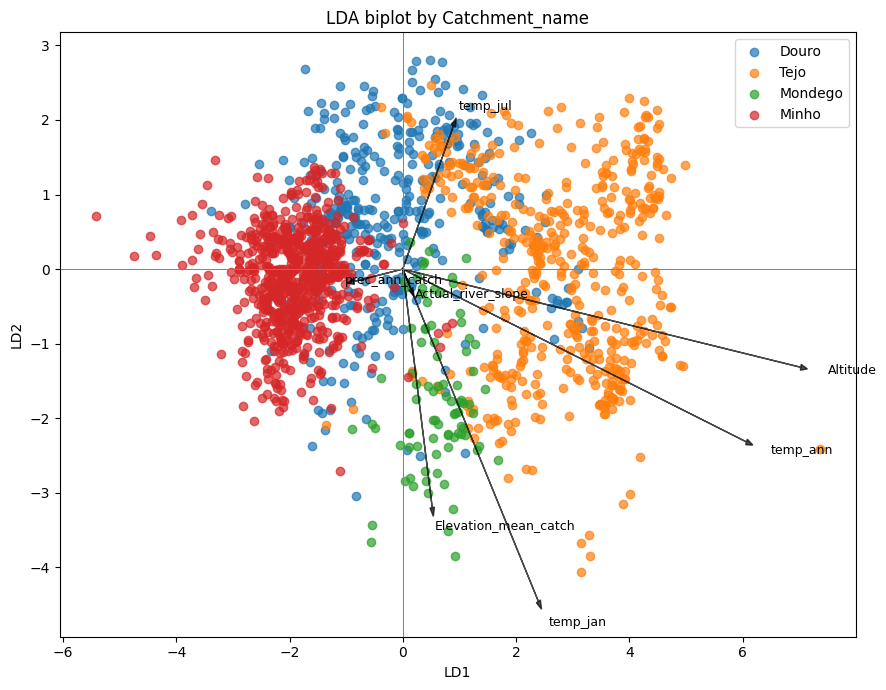

In [3]:
# Static biplot
plt.figure(figsize=(9, 7))
for basin in basins:
    mask = scores["Catchment_name"] == basin
    plt.scatter(scores.loc[mask, "LD1"], scores.loc[mask, "LD2"], label=basin, alpha=0.7)

arrow_scale = 2
for var in env_vars:
    x = loadings.loc[var, "LD1"] * arrow_scale
    yv = loadings.loc[var, "LD2"] * arrow_scale
    plt.arrow(0, 0, x, yv, color="black", alpha=0.7, head_width=0.08, length_includes_head=True)
    plt.text(x * 1.05, yv * 1.05, var, fontsize=9)

plt.axhline(0, color="grey", lw=0.7)
plt.axvline(0, color="grey", lw=0.7)
plt.xlabel("LD1")
plt.ylabel("LD2")
plt.title("LDA biplot by Catchment_name")
plt.legend()
plt.tight_layout()
plt.show()


In [4]:
# Interactive biplot
fig2 = go.Figure()

for basin in basins:
    grp = scores[scores["Catchment_name"] == basin]
    fig2.add_trace(go.Scatter(
        x=grp["LD1"],
        y=grp["LD2"],
        mode="markers",
        name=basin,
        text=grp["Site_code"],
        hovertemplate="Catchment=%{fullData.name}<br>Site=%{text}<br>LD1=%{x:.2f}<br>LD2=%{y:.2f}<extra></extra>"
    ))

for var in env_vars:
    x = loadings.loc[var, "LD1"] * arrow_scale
    yv = loadings.loc[var, "LD2"] * arrow_scale
    fig2.add_annotation(x=x, y=yv, ax=0, ay=0, showarrow=True, arrowhead=3)
    fig2.add_annotation(x=x*1.08, y=yv*1.08, text=var, showarrow=False)

fig2.update_layout(
    title="Interactive LDA biplot",
    xaxis_title="LD1",
    yaxis_title="LD2"
)
fig2.show()

#Interpertion
###Using the subset of sites from the Douro, Tejo, Mondego and Minho basins, a Linear Discriminant Analysis (LDA) was performed on standardized quantitative environmental predictors (Altitude, Actual_river_slope, Elevation_mean_catch, prec_ann_catch, temp_ann, temp_jan and temp_jul), with Catchment_name specified as the a priori grouping factor.

###The first two discriminant functions provided a low-dimensional representation in which the four basins were clearly separated: Tejo sites displayed markedly positive scores on LD1, while Minho sites occupied the negative side of LD1, indicating that Tejo is characterized by relatively warmer and lower-lying conditions, whereas Minho corresponds to cooler, higher-altitude environments. Mondego sites tended to show strongly negative LD2 scores, distinguishing them from the other basins along a secondary gradient largely associated with combinations of slope and catchment elevation, while Douro sites occupied more intermediate positions, albeit with a tendency towards positive LD2 scores.
###The loadings (scalings) of the discriminant functions showed that temperature variables contributed positively to LD1 and altitude and elevation contributed negatively, confirming that the main axis of discrimination reflects a warm lowland–cool highland gradient, whereas LD2 captured additional variation related to topographic and hydrological differences among catchments. Interactive scatter plots and biplots constructed in the space defined by LD1 and LD2, with points coloured by Catchment_name and equipped with hover information on site code and environmental values, further facilitated the exploration of these patterns by allowing dynamic inspection of individual sites and the contribution of each predictor to the observed separation among basins.